# Instruction Of the code
## Function in the code
There are three mainly function in this code
* LBP(img,window_size,plot_graph=False) #input image and window_size,will return lbp's image and histogram of each window
* plot_compare(window_size,threshold) #it will show the heatmap
## How to run the code
* Directly run all cells of the code, the result will show on the screen
## Read the video
put the data in the folder called datasetA,and save all the name of the image by the following
> ***datasetA***
> 
>    car-1.png
> 
>    car-*.png
> 
>    face-1.png
> 
>    face-*.png

# Texture Classification
The Local Binary Pattern (LBP) operator describes the surroundings of a pixel by generating a bit-code 
from the binary derivatives of a pixel.

## (a)
Write a function that divides a greyscale image into equally sized non-overlapping windows and 
returns the feature descriptor for each window as distribution of LBP codes. For each pixel in the 
window, compare the pixel to each of its 8 neighbours. Convert the resulting bit-codes (base 2) to 
decimals (base 10 numbers) and compute their histogram over the window. Normalize the histogram 
(which is now a feature descriptor representing the window). Show in the report the resulting images.

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def check_windowSize(img,window_size):
    #TO_DO: check the window_size can divide by height or width
    #       If cannot divide, raise Error and print the acceptable factor list
    height,width=img.shape
    factor_height=[]
    factor_width=[]
    for i in range(1, height + 1):
        if height % i == 0:
            factor_height.append(i)
    for i in range(1, width + 1):
        if width % i == 0:
            factor_width.append(i)
            
    common_numbers = set(factor_height).intersection(set(factor_width))
    
    if window_size in common_numbers:
        print("<Window_size fit!>")
    else:
        lst=sorted(list(common_numbers))
        raise ValueError("Window size you enter can't divide by height and width\nBelow is the accetable value: ",lst)

In [4]:
def zeropad(img,N):
    if math.isnan(np.mean(img)):
        a=0
    else:
        a=round(np.mean(img))
    height,width=img.shape
    padding=(N//2)
    img_zero=np.full((height+padding*2,width+padding*2),a)
    for y in range(height):
        for x in range(width):
            img_zero[y+padding][x+padding]=img[y][x]
    return img_zero.astype("uint8")

In [5]:
def convolution(img):
    #Apply zero padding to the image
    img_zero=zeropad(img,3)
    
    #create output image
    height,width=img.shape
    output=np.zeros((height,width))

    #doing convolution to image:
    for y in range(height):
        for x in range(width):
            C=[img_zero[y+1][x+1]]*8
            window_lst=[img_zero[y][x],img_zero[y][x+1],img_zero[y][x+2],img_zero[y+1][x+2],img_zero[y+2][x+2],img_zero[y+2][x+1],img_zero[y+2][x],img_zero[y+1][x]]
            lbp_list = [int(min(pair)==pair[1]) for pair in zip(window_lst, C)]
            binary_string = ''.join(str(bit) for bit in lbp_list)
            output[y][x]=int(binary_string, 2)
    return output.astype("uint8")

In [6]:
def histogram(img):
    height,width=img.shape
    h=np.zeros((256))
    h=h.astype(int)
    for y in range(height):
        for x in range(width):
            color=int(img[y][x])
            h[color]+=1
    return h

In [7]:
def plot_histogram(h):
    plt.figure(figsize=(12, 4))
    
    plt.bar(range(len(h)), h, width=1.0, color='b')
    plt.title('Histogram')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [8]:
def LBP(img,window_size,plot_graph=False):
    #check the window_size
    check_windowSize(img,window_size)
    height,width=img.shape
    lbp=np.zeros((height,width))
    tempy,tempx=0,0
    i,j=0,0
    hist=[]
    count=0
    while(True):
        count+=1
        img_grid=img[tempy:tempy+window_size,tempx:tempx+window_size].astype("uint8")
        output=convolution(img_grid)
        if np.sum(output)!=0:
            h=histogram(output)
            hist.append(h)
            lbp[tempy:tempy+window_size,tempx:tempx+window_size]=output[0:window_size,0:window_size]

        if plot_graph:
            if count==1 or count==8 or count==13:
                plt.figure()
                plt.title("window"+str(count))
                plt.imshow(img_grid,cmap='gray')
                plt.figure()
                plt.title("lbp"+str(count))
                plt.imshow(output,cmap='gray')
                plt.figure()
                plt.title("histogram"+str(count))
                plt.plot(h)
                plt.show()
            
        #move the non-overlapping windows
        if(tempx==width):
            if(tempy==height):
                break
            i+=1
            tempy,tempx=window_size*i,0
            j=0
            continue
        j+=1
        tempx=window_size*j 
    return lbp.astype("uint8"),hist

In [9]:
def readimage(window_size):
    #read face
    lbp_face, hist_face=[],[]
    for i in range(3):
        name="datasetA/face-"+str(i+1)+".jpg"
        img=cv2.imread(name)
        img= cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        lbp, hist=LBP(img,window_size)
        lbp_face.append(lbp)
        hist_face.append(hist)
    
    #read car
    lbp_car, hist_car=[],[]
    for i in range(3):
        name="datasetA/car-"+str(i+1)+".jpg"
        img=cv2.imread(name)
        img= cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        lbp, hist=LBP(img,window_size)
        lbp_car.append(lbp)
        hist_car.append(hist)

    return lbp_face,lbp_car,hist_face,hist_car

In [10]:
lbp_face,lbp_car,hist_face,hist_car=readimage(64)

<Window_size fit!>


/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Window_size fit!>
<Window_size fit!>
<Window_size fit!>
<Window_size fit!>
<Window_size fit!>


<Window_size fit!>


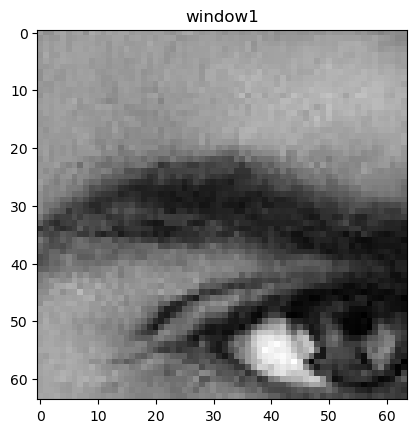

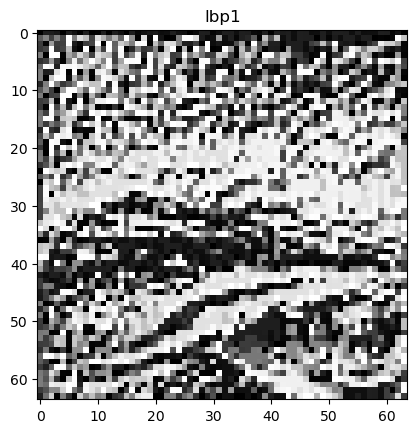

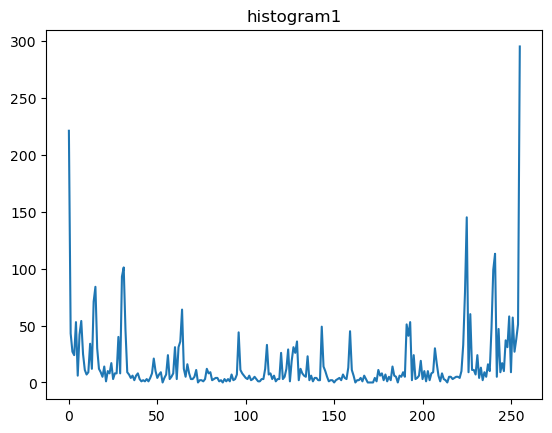

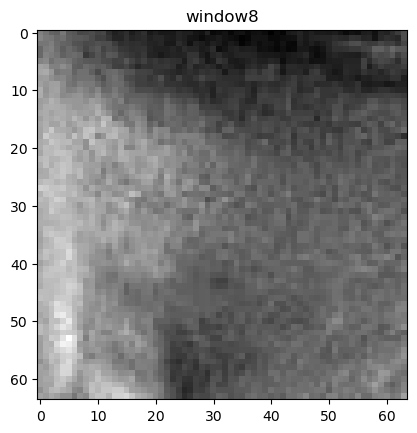

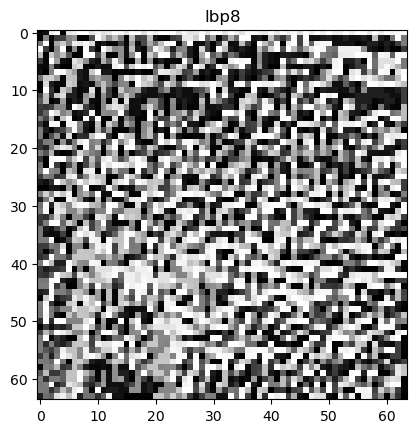

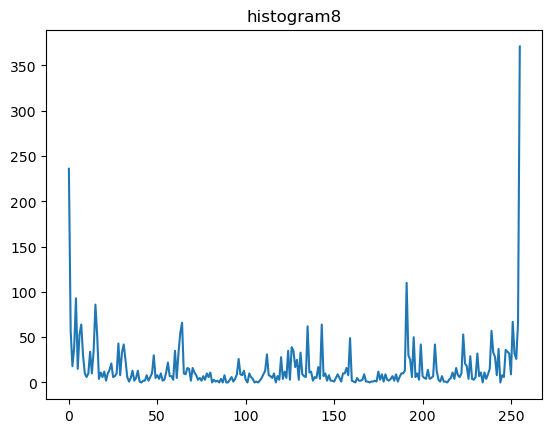

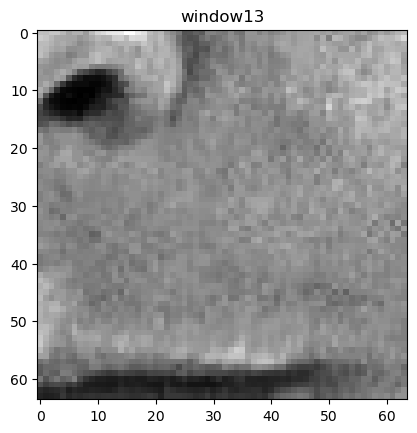

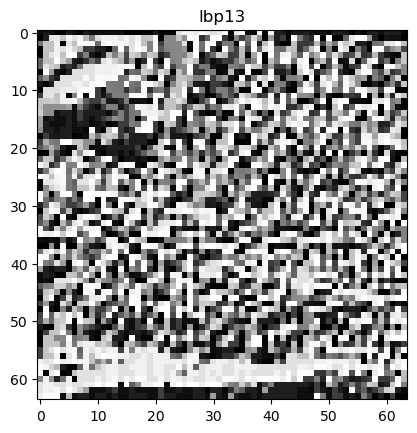

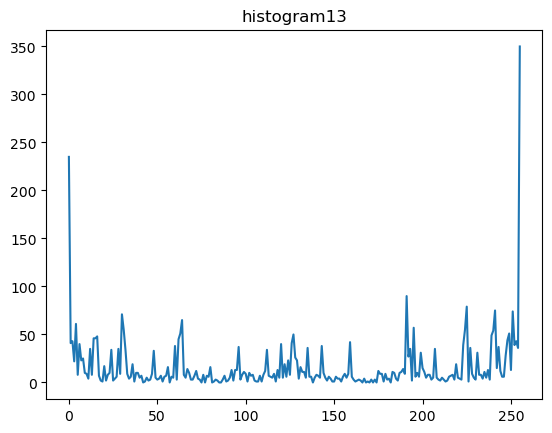

In [11]:
img=cv2.imread("datasetA/face-1.jpg")
img= cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
lbp, hist=LBP(img,64,True)

## (b)
Come up with a descriptor that represents the whole image as consisting of multiple windows. For 
example, you could combine several local descriptions into a global description by concatenation.
Discuss in the report alternative approaches. Using the global descriptor you created, implement a 
classification process that separates the images in the dataset into two categories: face images and 
non-face images (for example, you could use histogram similarities). Comment the results in the 
report. Is the global descriptor able to represent whole images of different types (e.g. faces vs. cars)? 
Identify problems (if any), discuss them in the report and suggest possible solutions.

In [12]:
def global_descriptor(h):
    temp=np.array(h).transpose()
    hist=[]
    for i in range(len(temp)):
        hist.append(np.sum(temp[i]))
    return hist

In [13]:
def euclidean_distance(h1,h2):
    sum=0
    for i in range(len(h1)):
        sum+=abs((h1[i]-h2[i]))*abs((h1[i]-h2[i]))
    return np.sqrt(sum)

In [14]:
def eu_dist(gd1,gd2):
    dist=euclidean_distance(gd1,gd2)
    return dist

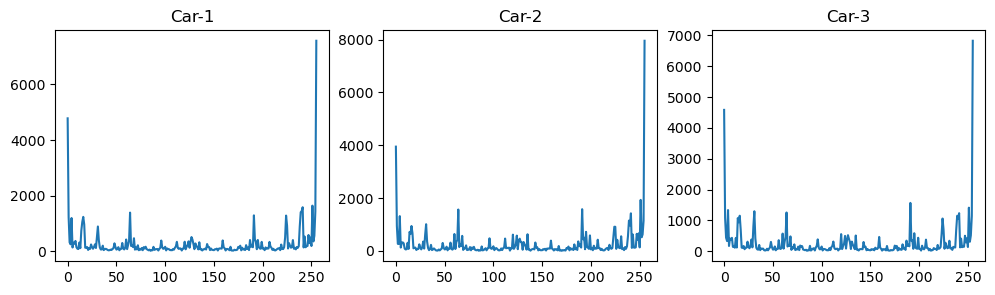

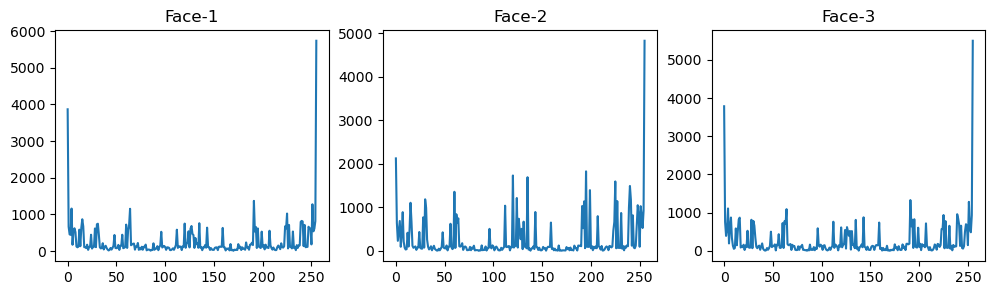

In [15]:
plt.figure(figsize=(12,3))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.plot(global_descriptor(hist_car[i]))
    plt.title("Car-"+str(i+1))
plt.figure(figsize=(12,3))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.plot(global_descriptor(hist_face[i]))
    plt.title("Face-"+str(i+1))

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
def plot_compare(window_size,threshold=0.4):
    lbp_face,lbp_car,hist_face,hist_car=readimage(window_size)
    GD=[]
    #GD is the global descriptor of car1,2,3 -> face1,2,3
    for i in range(3):
        GD.append(global_descriptor(hist_car[i]))
    for i in range(3):
        GD.append(global_descriptor(hist_face[i]))

    comp=[]
    for x in range(len(GD)):
        temp=[]
        for y in range(len(GD)):
            temp.append(eu_dist(GD[x],GD[y]))
        comp.append(temp)
    comp=comp/np.max(comp)
    #plot the heat map
    sns.heatmap(comp, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title("The heatmap of Euclidean distance with window size="+str(window_size))
    plt.xticks(ticks=[0.5, 1.5, 2.5,3.5,4.5,5.5], labels=['car1','car2','car3','face1','face2','face3'])
    plt.yticks(ticks=[0.5, 1.5, 2.5,3.5,4.5,5.5], labels=['car1','car2','car3','face1','face2','face3'])
    plt.show()


    for i in range(len(comp)):
        for j in range(len(comp[i])):
            if comp[i][j] < threshold:
                comp[i][j]=0
            else:
                comp[i][j]=1
    #plot the heat map after threshold
    sns.heatmap(comp, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title("threshold value="+str(threshold))
    plt.xticks(ticks=[0.5, 1.5, 2.5,3.5,4.5,5.5], labels=['car1','car2','car3','face1','face2','face3'])
    plt.yticks(ticks=[0.5, 1.5, 2.5,3.5,4.5,5.5], labels=['car1','car2','car3','face1','face2','face3'])
    plt.show()


<Window_size fit!>


/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Window_size fit!>
<Window_size fit!>
<Window_size fit!>
<Window_size fit!>
<Window_size fit!>


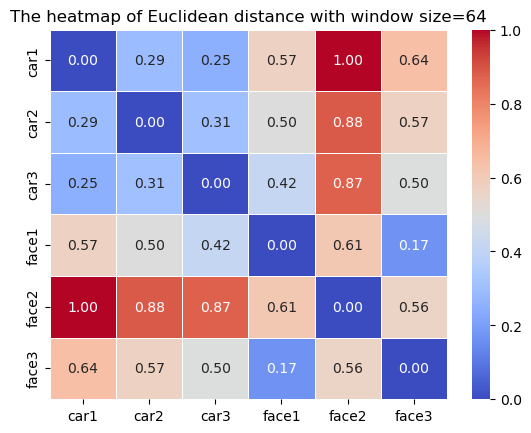

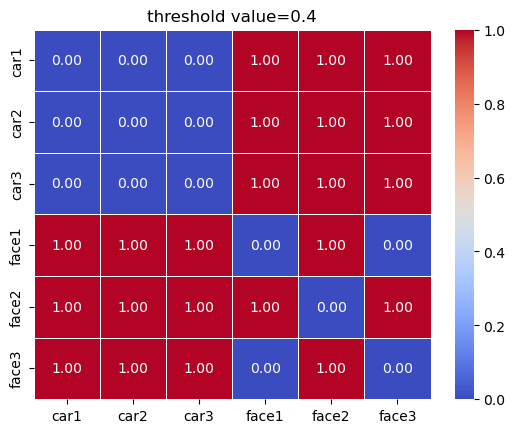

In [18]:
plot_compare(64,0.4)

## (c)
Decrease the window size and perform classification again. Comment the results in the report.

<Window_size fit!>


/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Window_size fit!>
<Window_size fit!>
<Window_size fit!>
<Window_size fit!>
<Window_size fit!>


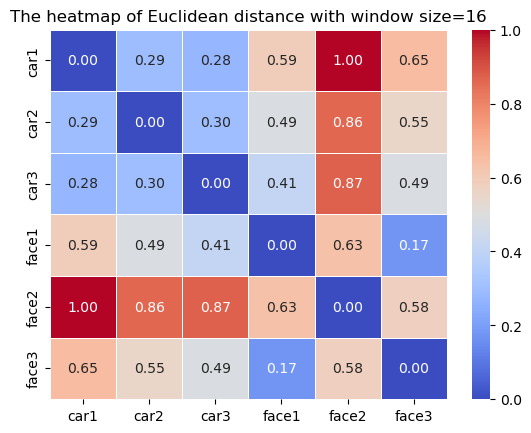

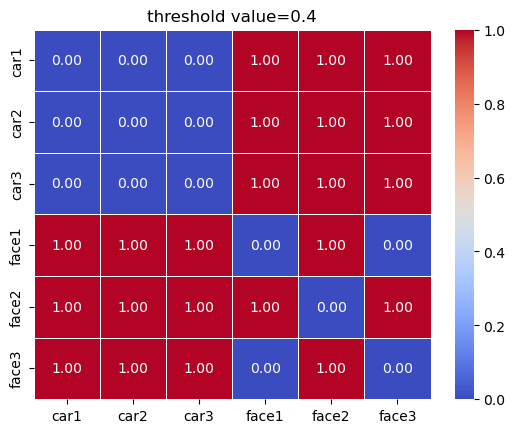

In [19]:
plot_compare(16,0.4)

## (d)
Increase the window size and perform classification again. Comment the results in the report. 

<Window_size fit!>


/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Window_size fit!>
<Window_size fit!>
<Window_size fit!>
<Window_size fit!>
<Window_size fit!>


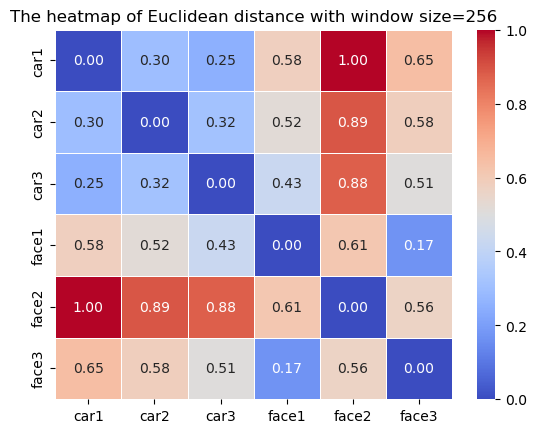

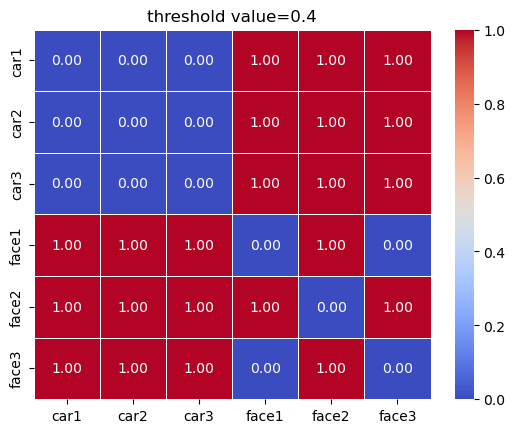

In [20]:
plot_compare(256,0.4)

## (e)
Discuss how LBP can be used or modified for the analysis of dynamic textures in a video